# Task 1. Visualizing L1 regression

In this task, we'll be working again with the familiar Australian rain dataset.

I'm including some basic preprocessing code for your convenience:

In [ ]:
!gdown 1oDLRJgsOl_s_5FTbmL0XASp0-glW697E # download weatherAUS.csv

Downloading...
From: https://drive.google.com/uc?id=1oDLRJgsOl_s_5FTbmL0XASp0-glW697E
To: /content/weatherAUS.csv
100% 14.1M/14.1M [00:00<00:00, 39.2MB/s]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Load dataset

df = pd.read_csv('weatherAUS.csv')
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Drop rows with any NaN values
df = df.dropna()

# Drop unused columns
X = df.drop(columns=['RainTomorrow', 'Date'])
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Define the preprocessing for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler(with_std=True))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train).toarray()
X_test_prep = preprocessor.transform(X_test).toarray()

Now, your tasks are:

**Task 1.1.** Write in `pytorch` the function `sgd_logistic_regression`, that:
- Trains a logistic regression model with gradient descent.
- Outputs training loss value after each epoch. Note that if you use regularization, you need to output non-regularized log-loss, because that's what is important for you in the end.
- Outputs `metrics` on both the training and test set after each epoch.
- Saves `w` and `b` values after each batch to a log.
- Returns the final trained `w` and `b` and also their batch-wise history log (you'll need it later)

Test your function on logistic regression without regularization. Try different learning rates and batch sizes. Try to feel which work better or worse for you.

**Hints and suggestions:**
- Use `torch.optim.SGD` instead of manual updates.
- Don't forget to zero the gradients!
- Don't forget to randomize the order of training data at the beginning of each epoch!
- You have options of getting sigmoid + log-loss. I'd recommend you code them manually, but you can also rely on whatever exists in the `torch` library. However, be careful with them: different choices may improve or harm your optimization processes. If you decide to code it yourself, I very much recommend clamping the predicted class 1 probability
```
y_pred = # SIGMOID(LOGITS)
epsilon = 1e-15  
y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
log_loss = # <SMTH FROM y_pred>
```
This might save you from having problems when you apply logarithm to the output of a sigmoid. You have both $\log(y_pred)$ and $\log(1-y_pred)$ there, so you definitely don't want `y_pred` to approach either $0$ or $1$.


In [ ]:
import torch

def sgd_logistic_regression(
    X_train, y_train, # What we train the model on
    X_val, y_val, # For checking the metrics after each epoch
    lr=0.01, epochs=20, batch_size=100, # Optimization parameters
    penalty='l2', # Can also be 'no' and 'l1'
    reg_lambda=1, # Regularization coefficient
    metrics=[f1_score] # Metrics to output between epochs
    ):

    # Convert data to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Reshape for binary classification

    # <YOUR CODE HERE>

    # Training loop
    for epoch in range(epochs):
        # <YOUR CODE HERE>

        # Print progress
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
        with torch.no_grad():
            # <MAKE PREDICTIONS ON TRAIN AND TEST HERE TO COMPUTE METRICS>



    return w.detach().numpy(), b.detach().numpy(), points

**Task 1.2.** Train an L1-regularized logistic regression. This won't be easy. An L1-regularized model may be capricious during training. What to be aware of:

1. Try initializing `w` with both all zeros and random numbers and check how these two options work out. The first one is safer. The second one may give you `nan` (Not A Number) quite often, because the loss would diverge. So, I'd suggest multiplying a randomized initialization on, say, $0.01$.

  Note that `w = 0.01*torch.randn(1, n_features, requires_grad=True)` makes `w` not a leaf vertex of the computational graph, which will lead to torch refusing to compute its gradient. A possible (and not a unique) workaround is:

  ```
  w = torch.randn(1, n_features, requires_grad=True)  # Weight vector
  with torch.no_grad():
      w *= 0.01
  ```

2. You'll need to experiment with optimization parameters and the regularization strength $\lambda$ to make things work. Try achieving F1 score on test at least $0.62$.

In [ ]:
# <YOUR CODE HERE>

**Task 1.3.** As we've discussed in class, L1-regularization of sufficient strength (`reg_lambda=1` will work in for our dataset) sparsifies features, zeroing a significant number of weights. Unfortunately, with SGD we won't get zeroes, because of uncertain behaviour of $|x|$ in zero (this would require more advanced techniques). But you should be able to see significant contrast between "almost zeroed" features with $|w_i|\leqslant 10^{-8}$ and the remaining ones with $|w_j|$ several order of magnitude larger.

You task will be the following:
1. You should have obtained the log from `sgd_logistic_regression`, which contains the history of how $w_j$ changed from batch to batch. Take $w_j$ that converge to $\sim10^{-8}$ or less and plot each one's evolution, all on one plot. I suggest doing for both zero-initialized `w` and randomly initialized `w`.
2. Look at the evolution patterns. What do they have in common? Try to explain from the gradient descent point of view why these $w_j$ reach near-zero values and why they stay there.

If you want to know more about how L1-regularized losses are optimized, I'd suggest checking [this post](https://blog.omega-prime.co.uk/2020/04/01/l1-regression/) which seems to have both code and theoretical explanations. Of most interest is, to my mind, *proximal gradient descent*.

**Task 1.4.** If you're in a mood for some math, I encourage you to find the gradient of log-loss with respect to the weights `w` (for simplicity you may consider that there is no bias term `b`) and to write it without sums, as a matrix expression. The following formula may be of help:
$$\sigma(z)' = \sigma(z)(1 - \sigma(z))$$
(check it!)

## Solution

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def predict_with_log_regression(X_test, w_trained, b_trained):
    # X_test_prep = np.array(X_test_prep)
    # w_trained = np.array(w_trained)

    logits = np.dot(X_test, w_trained.T) + b_trained
    prob_pred = 1 / (1 + np.exp(-logits))

    # Classify based on probability (threshold 0.5)
    y_pred = (prob_pred >= 0.5).astype(int)

    return y_pred, prob_pred


def sgd_logistic_regression(X_train, y_train,
                            X_val, y_val,
                            lr=0.01, epochs=100, batch_size=32,
                            penalty='l2', reg_lambda=1):
    # Convert data to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Reshape for binary classification

    # Initialize model parameters
    n_features = X_train.shape[1]
    w = torch.randn(1, n_features, requires_grad=True)  # Weight vector
    with torch.no_grad():
        w *= 0.01 # Without this, SGD would quite often refuse to converge
    b = torch.zeros(1, requires_grad=True)  # Bias scalar; it's usually initialized with zeros

    points = [w.clone().detach().numpy()]

    # Define the sigmoid function
    def sigmoid(x):
        return 1 / (1 + torch.exp(-x))

    # Define the loss function (Binary Cross-Entropy)
    loss_fn = nn.BCELoss()
    # Define optimizer
    optimizer = optim.SGD([w, b], lr=lr)

    # Training loop
    for epoch in range(epochs):
        # Shuffle the data at the beginning of each epoch
        perm = torch.randperm(X_train.shape[0])

        # Mini-batch training
        for start_idx in range(0, X_train.shape[0], batch_size):
            end_idx = start_idx + batch_size
            X_batch = X_train_tensor[perm[start_idx:end_idx]]
            y_batch = y_train_tensor[perm[start_idx:end_idx]]

            # Forward pass
            logits = X_batch @ w.T + b
            y_pred = sigmoid(X_batch @ w.T + b)
            epsilon = 1e-15
            y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)


            loss = - torch.mean(
                + y_batch * torch.log(y_pred)
                + (1 - y_batch) * torch.log(1 - y_pred)
                )
            '''
            You could also do it with torch layers: Linear layer, Sigmoid layer and the BCELoss
            torch also has a specialized layer combining them all:
                loss = torch.nn.BCEWithLogitsLoss(reduction='mean')(y_batch, logits)
            But for me it worked worse; maybe I somehow misused it
            '''


            if penalty == 'l2':
                loss += reg_lambda * torch.sum(w ** 2) * batch_size/X_train.shape[0]
            elif penalty == 'l1':
                loss += reg_lambda *torch.norm(w, 1) * batch_size/X_train.shape[0]
            '''
            Regularization term is multiplied on batch_size / whole_data_size
            This helps to balance gradients of log-loss and the regularization term
            '''

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            w_np = w.clone().detach().numpy()
            b_np = b.clone().detach().numpy()
            points.append(w_np)

        # Print progress (optional)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
        with torch.no_grad():
            w_np = w.clone().detach().numpy()
            b_np = b.clone().detach().numpy()
            y_pred, prob_pred = predict_with_log_regression(X_train, w_np, b_np)
            f1 = f1_score(y_train, y_pred)
            print(f'\t\t F1 Score on train: {f1:.4f}')

            y_pred, prob_pred = predict_with_log_regression(X_val, w_np, b_np)
            f1 = f1_score(y_val, y_pred)
            print(f'\t\t F1 Score on validation: {f1:.4f}')



    return w.detach().numpy(), b.detach().numpy(), points

Choosing the right parameters was not so simple; here is what worked for me:

In [ ]:
w_trained, b_trained, points = sgd_logistic_regression(X_train_prep, y_train.to_numpy(),
                        epochs=5, batch_size=1000, lr=0.01,
                        penalty='l1', reg_lambda=1)

Epoch [1/5], Loss: 0.6354
		 F1 Score on train: 0.6106
		 F1 Score on test: 0.6084
Epoch [2/5], Loss: 0.5677
		 F1 Score on train: 0.6173
		 F1 Score on test: 0.6173
Epoch [3/5], Loss: 0.5418
		 F1 Score on train: 0.6212
		 F1 Score on test: 0.6253
Epoch [4/5], Loss: 0.5227
		 F1 Score on train: 0.6239
		 F1 Score on test: 0.6281
Epoch [5/5], Loss: 0.5044
		 F1 Score on train: 0.6247
		 F1 Score on test: 0.6287


If we just plot the log of the absolute values of the trained weights, we'll see that many of them become quite small. They don't get too low, because we use naive SGD instead of proximal gradient descent or some other advanced method for optimizing non-smooth losses. But still, there is a stark difference.

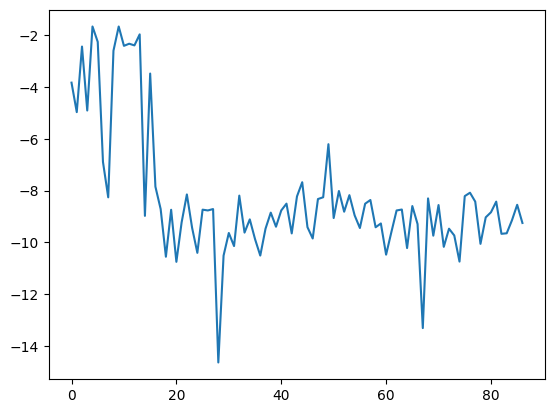

In [ ]:
import matplotlib.pyplot as plt

plt.plot(np.log(np.abs(w_trained[0])))

And now, let's plot the trajectories of the weights that become less than 1e-8 in absolute value in the end. You can observe that only a few of them try to become noticeable again; others, once diminished, stay like that forever.

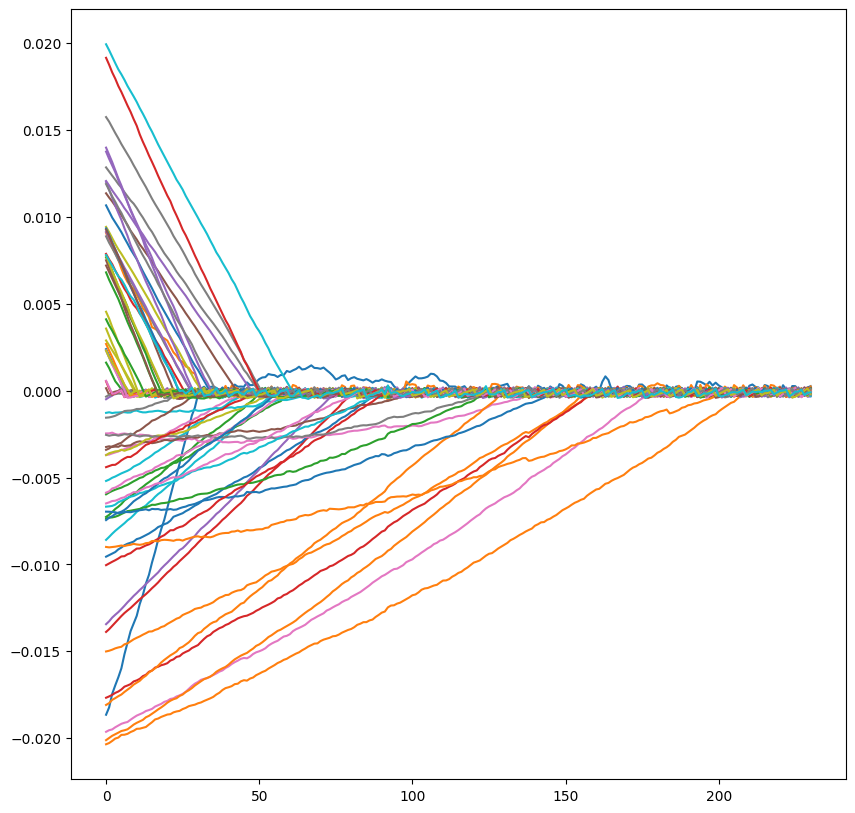

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

n_features = X_train_prep.shape[1]
coordinate_dynamics = [
    [w[0][i] for w in points] for i in range(n_features)
]

for i in range(n_features):
    if np.log(np.abs(coordinate_dynamics[i][-1])) < -8:
        plt.plot(coordinate_dynamics[i])

plt.show()

## An attempt at explaining the phenomenon

The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$

## Derivative of sigmoid

$$\sigma(z) = \frac1{1 + e^{-z}}$$

$$\sigma(z)' = -\frac1{(1 + e^{-z})^2}\cdot (-e^{-z}) = \frac1{1 + e^{-z}}\cdot\frac{e^{-z}}{1 + e^{-z}}=$$

$$=\frac1{1 + e^{-z}}\cdot\frac{1 + e^{-z} - 1}{1 + e^{-z}}=\frac1{1 + e^{-z}}\cdot\left(1 - \frac1{1 + e^{-z}}\right)=\sigma(z)(1 - \sigma(z))$$

In turn,

$$(\log{\sigma(z)})' = \frac1{\sigma(z)}\cdot\sigma(z)(1 - \sigma(z)) = 1 - \sigma(z)$$

And also

$$(\log(1 - \sigma(z)))' = \frac1{1 - \sigma(z)}\cdot\left[-\sigma(z)(1 - \sigma(z))\right] = - \sigma(z)$$

## Gradient of the log loss

$$\frac{\partial}{\partial w_j}\mathcal{L} = -\frac{\partial}{\partial w_j}\sum_{i=1}^N\left(y_i\log{\sigma(x_iw^T)} + (1-y_i)\log(1 -\sigma(x_iw^T))\right) =$$

Let's comment here that $\frac{\partial}{\partial w_j}\log{\sigma(x_iw^T)}=\frac{\partial}{\partial w_j}\log{\sigma\left[\sum_{j=1}^Dx_{ij}w_j\right]} = \underbrace{(1 - \sigma(x_iw^T))}_{(\log\sigma)'}\cdot \underbrace{x_{ij}}_{\frac{\partial}{\partial w_j}(x_iw^T)}$. So, we get

$$=-\sum_{i=1}^N\left(y_i(1 - \sigma(x_iw^T))x_{ij} + (1-y_i)(-\sigma(x_iw^T))x_{ij}\right)=$$

$$=-\sum_{i=1}^N\left(y_i - \sigma(x_iw^T)\right)x_{ij}$$

The overall gradient is

$$\nabla_w\mathcal{L} = -\left(y - \sigma(Xw^T)\right)^TX$$

Compare this to the linear regression's gradient

$$\nabla_w\mathcal{L}_{linreg} = -2\left(y - Xw^T\right)^TX$$

# Task 2. A seemingly simple optimization task

In this task, you will work with a very small and simple 2-dimensional dataset. Let's load it.

In [ ]:
!gdown 1SX531fBSC8G09_2-uaVN5cQbcZyh2FF2

Downloading...
From: https://drive.google.com/uc?id=1SX531fBSC8G09_2-uaVN5cQbcZyh2FF2
To: /content/small_data.npz
100% 2.89k/2.89k [00:00<00:00, 8.12MB/s]


In [ ]:
import numpy as np

# Load the data from the .npz file
data = np.load('small_data.npz')
X = data['X']
y = data['y']

print(X.shape, y.shape)

(100, 2) (100,)


Use your `sgd_logistic_regression` function to train logistic regression on this dataset (I actually suggest not using `b` at all here). You don't need to do train-test split, just use all the dataset for training. Set `batch_size=X.shape[0]` and `penalty='no'`.

Now, train your model for 10, 100, 1000, 10000 epochs. Look at the resulting `w`. Be surprised. Try to make sense of what's happening. Scatterplotting the data may actually help. Also, think about the loss: what we optimize and why loss optimization may lead to this.

In [ ]:
# <YOUR CODE HERE>

## Solution

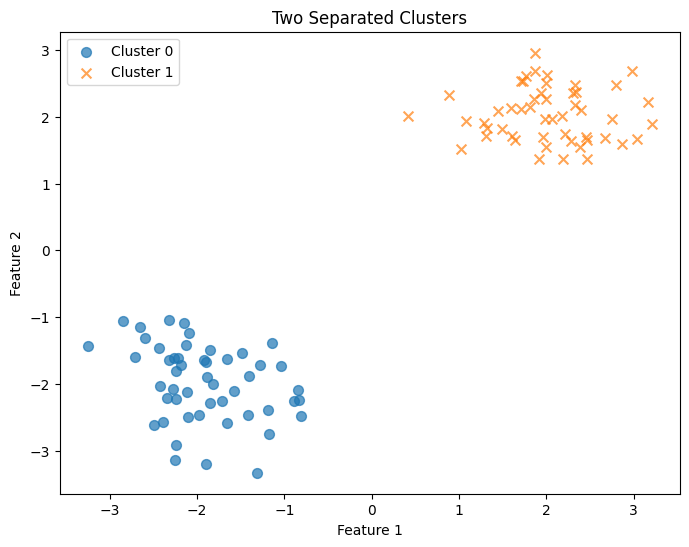

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_clusters(n_samples=100, n_features=2, centers=None, std=0.5):
    """Generates two separated clusters of points on the plane.

    Args:
        n_samples: The total number of samples to generate.
        n_features: The number of features (dimensions) for each sample.
        centers: A list of two centers (tuples or lists) for the two clusters.
        std: The standard deviation for each cluster.

    Returns:
        A tuple containing two numpy arrays:
            - X: The generated data points (n_samples x n_features).
            - y: The corresponding cluster labels (0 or 1) for each sample.
    """
    if centers is None:
      centers = [[-2, -2], [2, 2]]

    n_samples_per_cluster = n_samples // 2

    cluster1 = np.random.normal(loc=centers[0], scale=std, size=(n_samples_per_cluster, n_features))
    cluster2 = np.random.normal(loc=centers[1], scale=std, size=(n_samples - n_samples_per_cluster, n_features))

    X = np.concatenate((cluster1, cluster2), axis=0)
    y = np.concatenate((np.zeros(n_samples_per_cluster), np.ones(n_samples - n_samples_per_cluster)), axis=0)

    return X, y

# Example usage
X, y = generate_clusters()


# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Cluster 0', marker='o', s=50, alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Cluster 1', marker='x', s=50, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Two Separated Clusters')
plt.legend()
plt.show()

First of all, it's important to observe that the classes are **linearly separable**. That is, there is a line that ideally separates the classes. Actually, there are many lines. One of them is $x + y = 0$, defined by the weight vector $w = (1, 1)$.

In [ ]:
import numpy as np

np.savez('data.npz', X=X, y=y)

In [ ]:
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X, y, test_size=0.2, random_state=42)

Now let's perform gradient descent for 10000 epochs.

In [ ]:
%%capture
w_trained, b_trained, points = sgd_logistic_regression(X_train_2d, y_train_2d,
                                                       X_test_2d, y_test_2d,
                                                      epochs=10000, batch_size=X_train_2d.shape[0], lr=1,
                                                      penalty='no', reg_lambda=1)

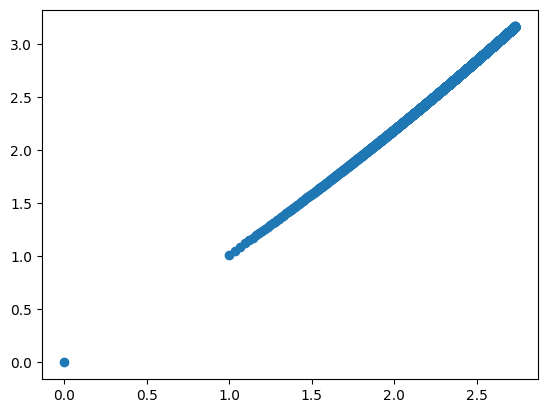

In [ ]:
plt.scatter([p[0][0] for p in points], [p[0][1] for p in points])

What we observe is: $w$ doesn't actually converge to anything. The more steps we have, the further we go, even though we move slower and slower. In this example we may also note that the values of $w$ stay multiples of $(1, 1)$, some $(t, t)$. Actually, they all describe the same line:
$$tx + ty = 0 \Leftrightarrow x + y = 0$$

To understand what's happening, we need to recall what exactly is optimized when we train logistic regression. The objective is: **predicted probability of true class -> max**. So, we not just optimize how well we guess classes, we also optimize the *confidence*:

* for objects of class 1 we want to predict **probability of class 1** ($=\sigma(xw^T)$) as close to 1 as possible, and
* for the objects of class 0 we want to predict **probability of class 0** ($=\sigma(-xw^T)$) as close to 1 as possible.

Now, sigmoid is a monotonically increasing function:

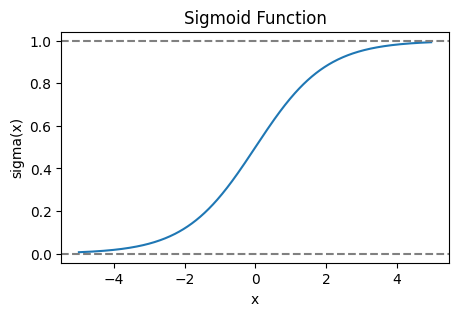

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

xx = np.arange(-5, 5, 0.02)
yy = sigmoid(xx)

plt.figure(figsize=(5, 3))
plt.plot(xx, yy)
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.title("Sigmoid Function")
plt.axhline(y=1, linestyle="--", color="grey")
plt.axhline(y=0, linestyle="--", color="grey")
plt.show()

So, imagine that $w$ already allows to perfectly separate the classes. Then

* For objects of class 1, $x_iw^T > 0$, and $x_i(tw)^T$ also $> 0$ for every $t > 0$. Moreover, if $t > 1$, then $x_i(tw)^T > x_iw^T$, hence $\sigma(x_i(tw)^T) > \sigma(x_iw^T)$,
* Just the same, for objects of class 0,  $\sigma(x_i(tw)^T) < \sigma(x_iw^T)$ for $t > 1$.

The takeaway is: if $w$ perfectly separates classes and $t > 1$, then $tw$ gives better confidence than $w$, hence better loss values. This is why gradient descent never stops: it just increases and increases $t$ never stopping the process. Note that it's very important here that classes are linearly separable. Otherwise, this wouldn't work.

You may also wonder why the change of $w$ gets slower and slower. Let's again look at the sigmoid:

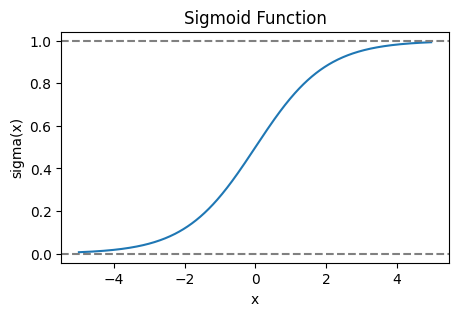

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

xx = np.arange(-5, 5, 0.02)
yy = sigmoid(xx)

plt.figure(figsize=(5, 3))
plt.plot(xx, yy)
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.title("Sigmoid Function")
plt.axhline(y=1, linestyle="--", color="grey")
plt.axhline(y=0, linestyle="--", color="grey")
plt.show()

As $w \mapsto tw$ with growing $t$, $|x_i(tw)^T|$ grows. And when $|z|$ grows, $z$ finds itself in the regions where $\sigma(z)$ is more and more flat: far to the right and far to the left $\sigma(z)$ becomes almost horizontal. And if it's flat, its gradient is close to $0$. And if gradients are small, gradient descent becomes slower and slower.

# Task 3. Analyzing European rivers with SVD

In this task you'll use SVD to analyze a subset of a dataset that provides information about the chemical composition of water in certain rivers. The credit for this dataset goes to [https://data.europa.eu/](https://data.europa.eu/); I would gladly share the link, but I can't find the dataset there any more :(

Let's load it right away:

In [ ]:
!gdown 11wOc9JlpLgOCxzrFZxMpiyB3aJ-Jj_lL # Waterbase_rivers_v14_Stations.csv
!gdown 1TMyvnU3FVKRvSmBq5sW0Ouxpzl9RLHL- # dataset_final

Downloading...
From: https://drive.google.com/uc?id=11wOc9JlpLgOCxzrFZxMpiyB3aJ-Jj_lL
To: /content/Waterbase_rivers_v14_Stations.csv
100% 5.45M/5.45M [00:00<00:00, 39.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TMyvnU3FVKRvSmBq5sW0Ouxpzl9RLHL-
To: /content/dataset_final
100% 2.19M/2.19M [00:00<00:00, 21.2MB/s]


In [ ]:
import pickle
index_list, feature_list, data_matrix = pickle.load(open('dataset_final', 'rb'))

A few words about the three entities we've unpacked:

- `index_list`: A list of river IDs selected for the task. (If you're curious to find out what these cryptic IDs represent, the explanations can be found in the table `Waterbase_rivers_v14_Stations.csv`, which we've conveniently downloaded from Google Drive.)
- `feature_list`: A list of features (formatted as `year SPACE indicator`).
- `data_matrix`: The data itself (rows correspond to the rivers in `index_list`, and columns correspond to the features in `feature_list`).

**Task 3.1.** Use SVD to create a 2d visualization of the dataset. For that, you'll need to take the first two "latent" features $\sigma_1u_1$ and $\sigma_2u_2$ and scatterplot the now-2-dimensional points. Initially, there will be some obstacles to good visualization; try to resolve them (hint: the obstacles are outliers and badly scaled features).

**Task 3.2.** Find which original features contribute the most to the first three "latent" features $\sigma_1u_1, \sigma_2u_2, \sigma_3u_3$ and try to guess the "physical meaning" of these features. For that, you'll need the vectors $v_1$, $v_2$, $v_3$: they contain the coefficients with which original features contribute to the new ones.

**Task 3.3.** Look at the visualization and ponder what you could say about rivers based on it.

In [ ]:
# <YOUR CODE HERE>

## Solution

How not to do this:

In [ ]:
from scipy.linalg import svd

U, S, Vt = svd(data_matrix)

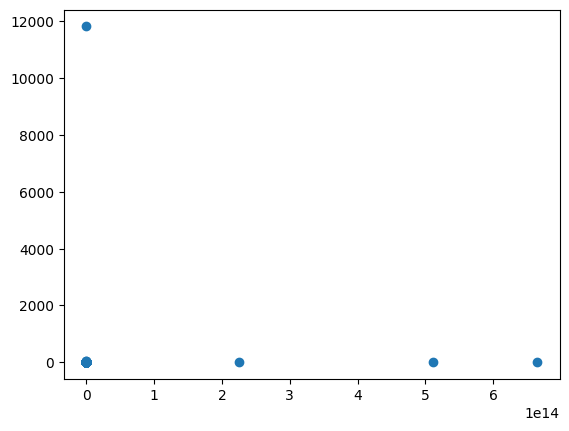

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(U[:, 0]*S[0], U[:, 1]*S[1])

Actually, we have a number of outliers in the data, and they dominate everything else. Most likely, thise are data collection errors. So, let's start by deleting them.

In [ ]:
import numpy as np

indices = np.where((U[:, 0]*S[0] > 1e+14) | (U[:, 1]*S[1] > 2000))[0]

indices

array([150, 183, 402, 476])

Let's check which features of the original data cause these problems:

In [ ]:
import numpy as np

for i in indices:
    sorted_indices = sorted(list(range(data_matrix.shape[1])),
                            key=lambda j: np.abs(data_matrix[i,j]), reverse=True)
    print(f"\nObject number {i}")
    for j in sorted_indices[:5]:
        print(f"- {j}-th feature value is: {np.abs(data_matrix[i,j])}")


Object number 150
- 453-th feature value is: 510606000000000.0
- 442-th feature value is: 989.0
- 455-th feature value is: 777.0
- 441-th feature value is: 32.0
- 451-th feature value is: 23.0

Object number 183
- 394-th feature value is: 11719.3
- 397-th feature value is: 1537.17
- 409-th feature value is: 110.675
- 390-th feature value is: 105.783
- 371-th feature value is: 103.2

Object number 402
- 453-th feature value is: 664394000000000.0
- 454-th feature value is: 135.0
- 455-th feature value is: 84.5
- 451-th feature value is: 76.0
- 420-th feature value is: 9.0

Object number 476
- 453-th feature value is: 225606000000000.0
- 442-th feature value is: 79.0
- 455-th feature value is: 73.0
- 451-th feature value is: 34.0
- 420-th feature value is: 5.875


Strange happenings indeed. Let's just manually impute the outlier values with column median:

In [ ]:
for i in indices:
    sorted_indices = sorted(list(range(data_matrix.shape[1])),
                            key=lambda j: np.abs(data_matrix[i,j]), reverse=True)
    column_copy = np.delete(data_matrix[:, sorted_indices[0]], i)
    data_matrix[i, sorted_indices[0]] = np.median(column_copy)

We could actually just drop these four rows, but that would later make mapping data points to real rivers more difficult.

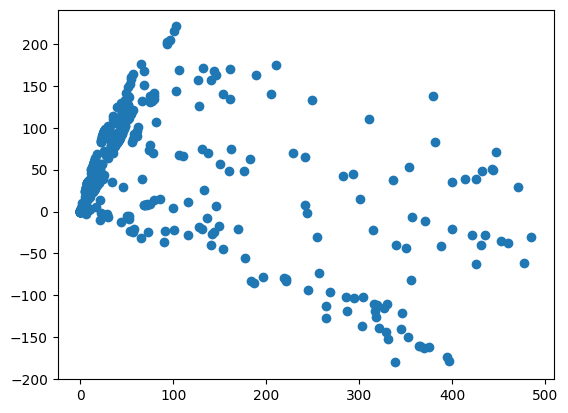

In [ ]:
data_matrix_new = np.delete(data_matrix, indices, axis=0)
U, S, Vt = svd(data_matrix_new)

plt.scatter(U[:, 0]*S[0], U[:, 1]*S[1])

It's curious to see which features contribute most to the first two components:

In [ ]:
sorted(zip(abs(Vt[0,:]), feature_list), reverse=True)[:20]

[(0.263451372946513, '2004 Oxygen saturation'),
 (0.25795965363291856, '2001 Oxygen saturation'),
 (0.2547948505732996, '2005 Oxygen saturation'),
 (0.2535107792591395, '2002 Oxygen saturation'),
 (0.2500617671401486, '2003 Oxygen saturation'),
 (0.24177668670783636, '2000 Oxygen saturation'),
 (0.2295507390113276, '1997 Oxygen saturation'),
 (0.22349088694155347, '1998 Oxygen saturation'),
 (0.22027526844136155, '1999 Oxygen saturation'),
 (0.21485015390590437, '2006 Oxygen saturation'),
 (0.2066405491623545, '2007 Oxygen saturation'),
 (0.19983094623269687, '2008 Oxygen saturation'),
 (0.19310900651792004, '1996 Oxygen saturation'),
 (0.18973495047930417, '1994 Oxygen saturation'),
 (0.1879775966650821, '1993 Oxygen saturation'),
 (0.1831704048306708, '1995 Oxygen saturation'),
 (0.16885494235667092, '1992 Oxygen saturation'),
 (0.15311124637174406, '2009 Oxygen saturation'),
 (0.1316181736587554, '1991 Oxygen saturation'),
 (0.1295950334239022, '1990 Oxygen saturation')]

In [ ]:
sorted(zip(abs(Vt[1,:]), feature_list), reverse=True)[:20]

[(0.4827026254129693, '2008 Oxygen saturation'),
 (0.3607357674409026, '2010 Oxygen saturation'),
 (0.3596986503711009, '2007 Oxygen saturation'),
 (0.35395019518351956, '2009 Oxygen saturation'),
 (0.3273374767307957, '2012 Oxygen saturation'),
 (0.22725022490147814, '2011 Oxygen saturation'),
 (0.1415988704463909, '2006 Oxygen saturation'),
 (0.12450431792862261, '1997 Oxygen saturation'),
 (0.12017689044842977, '1998 Oxygen saturation'),
 (0.12011396385852283, '1999 Oxygen saturation'),
 (0.11907078675194005, '2000 Oxygen saturation'),
 (0.11289678062041777, '1994 Oxygen saturation'),
 (0.1098034449222876, '2001 Oxygen saturation'),
 (0.10860829706854627, '1993 Oxygen saturation'),
 (0.10605584737266328, '1996 Oxygen saturation'),
 (0.09424938442568682, '2008 Dissolved oxygen'),
 (0.09417215923502775, '1992 Oxygen saturation'),
 (0.09150303560688043, '1995 Oxygen saturation'),
 (0.0892771823701854, '2002 Oxygen saturation'),
 (0.08475401277672326, '1990 Oxygen saturation')]

This is already better. We see here a tight cluster of points on the left with some kind of correlation between $\sigma_1 u_1$ and $\sigma_2 u_2$, for example. We also see that the first two features try to tell us some story about oxygen saturation in early 2000s vs late 2000s-early 2010s.

However, we have oxygen saturation at the top not because everything else is irrelevant. The thing is that we didn't normalize the data and, likely, we got larger features in the top. Let's quickly validate this hypothesis by printing std's of all the features in non-increasing order:

In [ ]:
std_devs = np.std(data_matrix_new, axis=0)
sorted_indices = np.argsort(std_devs)[::-1]

for j in sorted_indices:
    print(f"{feature_list[j]}: {std_devs[j]}")

2008 Dissolved oxygen: 46.69078337512552
2008 Oxygen saturation: 45.4214727828941
2007 Oxygen saturation: 43.4485758799492
2012 Oxygen saturation: 41.91134216233133
2007 CODCr: 40.79417781383919
2010 Oxygen saturation: 40.6425374054496
2009 Oxygen saturation: 39.720418006843005
2004 Oxygen saturation: 38.79370740748555
2005 Oxygen saturation: 38.33885370495536
2006 Oxygen saturation: 37.74700941046816
2003 Oxygen saturation: 37.69128371223448
2001 Oxygen saturation: 37.687068271757184
2011 Oxygen saturation: 36.323766264171844
2002 Oxygen saturation: 36.17452880899953
2000 Oxygen saturation: 35.399777066644155
1997 Oxygen saturation: 33.5402525501889
2008 pH: 33.446074001983995
1998 Oxygen saturation: 32.87469064796322
1999 Oxygen saturation: 32.74645900454314
1994 Oxygen saturation: 30.11522697699913
1996 Oxygen saturation: 30.098100126424754
1993 Oxygen saturation: 29.736138249846178
1995 Oxygen saturation: 28.71910118178662
1992 Oxygen saturation: 28.31424534703305
1991 Oxygen satur

You can see that oxygen saturation indeed have quite prominent std values.
This doesn't mean that the above visualization is meaningless. It can still provide insights about oxygen saturation in European rivers. But all other features were left behind.


Anyway, let's normalize the data.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=True, with_std=True)
data_matrix_norm = scaler.fit_transform(data_matrix_new)

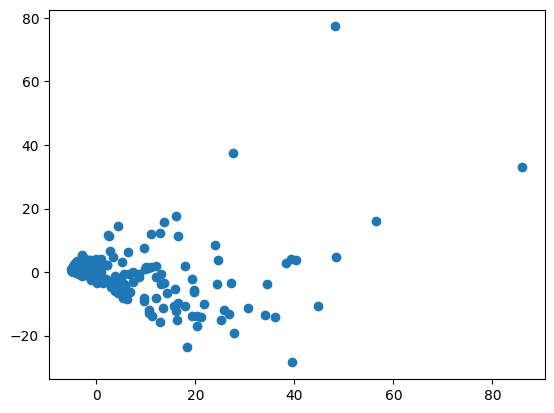

In [ ]:
U, S, Vt = svd(data_matrix_norm)

plt.scatter(U[:, 0]*S[0], U[:, 1]*S[1])

Again, let's understand which original features contribute most to these two latent features:

In [ ]:
sorted(zip(abs(Vt[0,:]), feature_list), reverse=True)[:20]

[(0.07615599385312732, '1992 Nitrate'),
 (0.07386837858216495, '1990 pH'),
 (0.0734743692874781, '1989 pH'),
 (0.07287950776736722, '1997 Nitrate'),
 (0.07285418475809864, '2002 Nitrate'),
 (0.0727595170878971, '1992 pH'),
 (0.072618181804116, '1991 pH'),
 (0.0719562471387986, '1997 Dissolved oxygen'),
 (0.07163277381127865, '1998 Nitrate'),
 (0.07122822937643805, '1996 Dissolved oxygen'),
 (0.0712120760632531, '1993 pH'),
 (0.0708837488895064, '1993 Nitrate'),
 (0.07053583640446395, '1988 pH'),
 (0.07053132604930508, '1996 pH'),
 (0.07050049054406493, '1992 Dissolved oxygen'),
 (0.07018019316571551, '1998 Dissolved oxygen'),
 (0.06985904971081071, '1987 pH'),
 (0.06966719505803462, '1990 Dissolved oxygen'),
 (0.06933316703244041, '1995 pH'),
 (0.06931682956499643, '1999 Nitrate')]

In [ ]:
sorted(zip(abs(Vt[1,:]), feature_list), reverse=True)[:20]

[(0.11515415828386028, '1994 Total ammonium'),
 (0.11396990766029583, '1998 Total ammonium'),
 (0.11113812034024496, '1997 Total ammonium'),
 (0.10765701932215509, '1993 Total ammonium'),
 (0.1075915772555517, '1999 Total ammonium'),
 (0.10615296294928574, '2002 Total ammonium'),
 (0.10476341475480475, '1992 Total ammonium'),
 (0.10436031296749239, '1995 Total ammonium'),
 (0.10250540456240508, '2002 Total phosphorus'),
 (0.10247605771649664, '2004 Total phosphorus'),
 (0.10105431072335087, '2000 Total ammonium'),
 (0.1000387270356643, '2006 Orthophosphates'),
 (0.09964209990880495, '2006 Nitrite'),
 (0.09892541742672488, '2005 Total phosphorus'),
 (0.09887552677480384, '2006 Total phosphorus'),
 (0.09880205110383314, '1994 Orthophosphates'),
 (0.09766534481790655, '2003 Total phosphorus'),
 (0.09685630171925624, '2003 Total ammonium'),
 (0.0968357424452548, '1999 Kjeldahl Nitrogen'),
 (0.09625201329872839, '1998 Kjeldahl Nitrogen')]

As we see, the list of top features changed drastically: it's now Nitrates/PH in the 90s vs total ammonium in the 90s.